# EDA

## Análise

## Quais aeroportos são mais críticos em relação a atrasos?



In [7]:
# =====================================================
# Setup
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

pd.set_option("display.max_columns", None)

In [8]:
# =====================================================
# Load Data
# =====================================================

flights_path = "../data/raw/flights.csv"
airports_path = "../data/raw/airports.csv"

df_flights = pd.read_csv(flights_path)
df_airports = pd.read_csv(airports_path)

print("Flights shape:", df_flights.shape)
print("Airports shape:", df_airports.shape)

df_flights.head()

C:\Users\jcbmc\AppData\Local\Temp\ipykernel_7204\65784135.py:8: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  df_flights = pd.read_csv(flights_path)


Flights shape: (5819079, 31)
Airports shape: (322, 7)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# =====================================================
# Seleção de colunas relevantes
# =====================================================

cols = [
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "ARRIVAL_DELAY",
    "DEPARTURE_DELAY",
    "CANCELLED"
]

df = df_flights[cols].copy()

df.head()

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,ARRIVAL_DELAY,DEPARTURE_DELAY,CANCELLED
0,ANC,SEA,-22.0,-11.0,0
1,LAX,PBI,-9.0,-8.0,0
2,SFO,CLT,5.0,-2.0,0
3,LAX,MIA,-9.0,-5.0,0
4,SEA,ANC,-21.0,-1.0,0


In [10]:
# =====================================================
# Limpeza
# =====================================================

# Remover cancelados
df = df[df["CANCELLED"] == 0]

# Remover nulos
df = df.dropna(subset=["ARRIVAL_DELAY", "DEPARTURE_DELAY"])

# Criar flag de atraso (>= 15 min é padrão mercado)
df["IS_DELAYED"] = df["ARRIVAL_DELAY"] > 15

df.describe()

,ARRIVAL_DELAY,DEPARTURE_DELAY,CANCELLED
count,5.714008e+06,5.714008e+06,5714008.0
mean,4.407057e+00,9.294842e+00,0.0
std,3.927130e+01,3.688972e+01,0.0
min,-8.700000e+01,-8.200000e+01,0.0
25%,-1.300000e+01,-5.000000e+00,0.0
50%,-5.000000e+00,-2.000000e+00,0.0
75%,8.000000e+00,7.000000e+00,0.0
max,1.971000e+03,1.988000e+03,0.0


In [11]:
# =====================================================
# Agregação por aeroporto de origem
# =====================================================

airport_metrics = (
    df.groupby("ORIGIN_AIRPORT")
    .agg(
        total_flights=("IS_DELAYED", "count"),
        avg_arrival_delay=("ARRIVAL_DELAY", "mean"),
        avg_departure_delay=("DEPARTURE_DELAY", "mean"),
        delay_rate=("IS_DELAYED", "mean")
    )
    .reset_index()
)

# Converter delay_rate para percentual
airport_metrics["delay_rate"] = airport_metrics["delay_rate"] * 100

airport_metrics.head()

,ORIGIN_AIRPORT,total_flights,avg_arrival_delay,avg_departure_delay,delay_rate
0,10135,226,7.601770,10.075221,16.814159
1,10136,181,-6.513812,2.270718,11.049724
2,10140,1702,0.320799,5.603995,11.985899
3,10141,66,0.606061,1.803030,10.606061
4,10146,81,11.987654,9.740741,13.580247


In [12]:
# =====================================================
# Join com airports
# =====================================================

df_airports.columns = df_airports.columns.str.upper()

airport_metrics = airport_metrics.merge(
    df_airports,
    left_on="ORIGIN_AIRPORT",
    right_on="IATA_CODE",
    how="left"
)

airport_metrics.head()

,ORIGIN_AIRPORT,total_flights,avg_arrival_delay,avg_departure_delay,delay_rate,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,10135,226,7.601770,10.075221,16.814159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10136,181,-6.513812,2.270718,11.049724,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10140,1702,0.320799,5.603995,11.985899,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10141,66,0.606061,1.803030,10.606061,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10146,81,11.987654,9.740741,13.580247,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# =====================================================
# Ranking de criticidade
# =====================================================

# Score simples (você pode evoluir depois)
airport_metrics["critical_score"] = (
    airport_metrics["delay_rate"] * np.log1p(airport_metrics["total_flights"])
)

top_critical = airport_metrics.sort_values(
    by="critical_score",
    ascending=False
).head(15)

top_critical[[
    "ORIGIN_AIRPORT",
    "AIRPORT",
    "CITY",
    "STATE",
    "total_flights",
    "delay_rate",
    "avg_arrival_delay"
]]

,ORIGIN_AIRPORT,AIRPORT,CITY,STATE,total_flights,delay_rate,avg_arrival_delay
835,ORD,Chicago O'Hare International Airport,Chicago,IL,276554,23.378798,8.600790
445,12266,NaN,NaN,NaN,715,40.699301,36.890909
789,LGA,LaGuardia Airport (Marine Air Terminal),New York,NY,94834,23.246937,5.628140
692,DEN,Denver International Airport,Denver,CO,193402,21.611979,7.187909
693,DFW,Dallas/Fort Worth International Airport,Dallas-Fort Worth,TX,232647,20.921396,6.918959
810,MIA,Miami International Airport,Miami,FL,68301,22.371561,7.040805
658,BWI,Baltimore-Washington International Airport,Baltimore,MD,84329,21.742224,7.248432
783,LAX,Los Angeles International Airport,Los Angeles,CA,192003,20.125727,5.723421
773,JFK,John F. Kennedy International Airport (New Yor...,New York,NY,91663,21.413220,3.607519
758,IAH,George Bush Intercontinental Airport,Houston,TX,144019,20.540345,7.378270


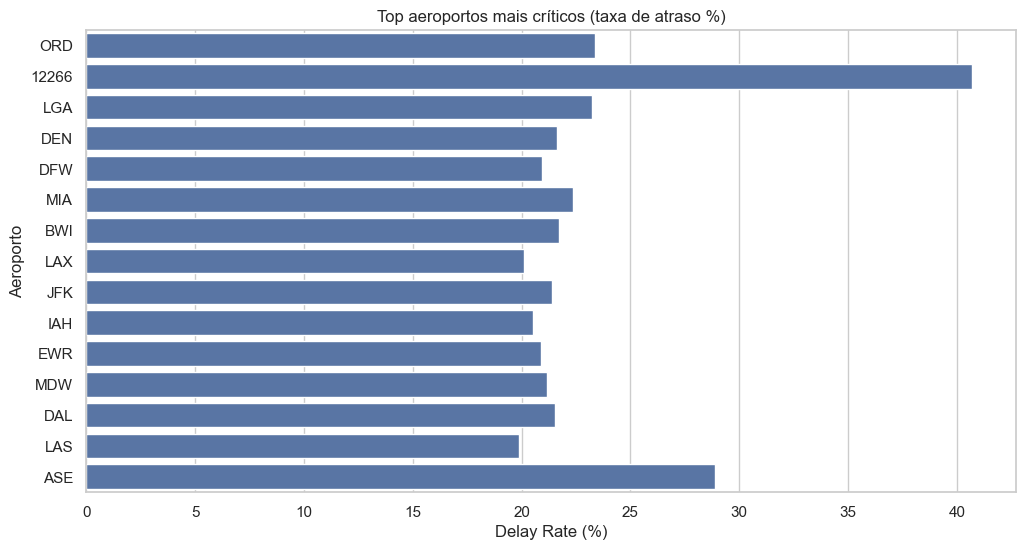

In [14]:
# =====================================================
# Gráfico - aeroportos críticos
# =====================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_critical,
    x="delay_rate",
    y="ORIGIN_AIRPORT"
)

plt.title("Top aeroportos mais críticos (taxa de atraso %)")
plt.xlabel("Delay Rate (%)")
plt.ylabel("Aeroporto")

plt.show()

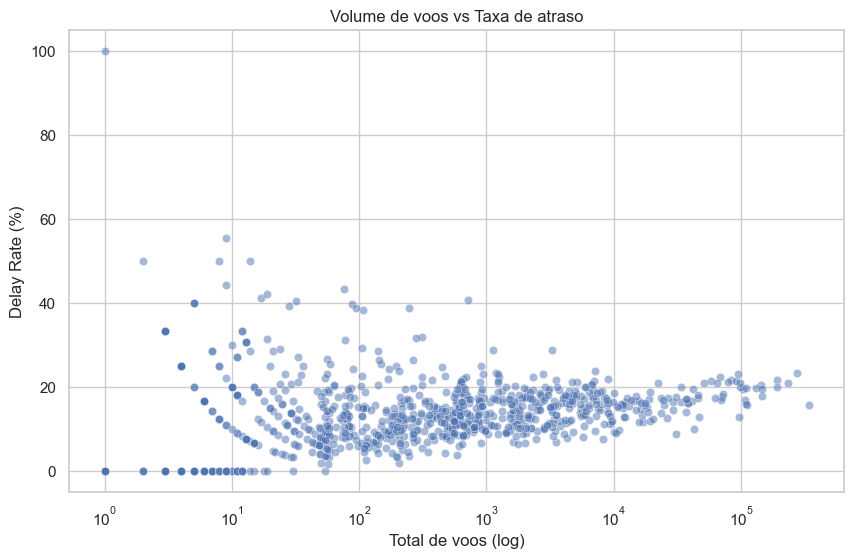

In [15]:
# =====================================================
# Scatter: volume vs atraso
# =====================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=airport_metrics,
    x="total_flights",
    y="delay_rate",
    alpha=0.5
)

plt.xscale("log")

plt.title("Volume de voos vs Taxa de atraso")
plt.xlabel("Total de voos (log)")
plt.ylabel("Delay Rate (%)")

plt.show()

In [16]:
# =====================================================
# Insights
# =====================================================

print("""
INSIGHTS:

1. Aeroportos com alto volume tendem a concentrar atrasos.
2. Alguns aeroportos menores apresentam alta taxa percentual de atraso.
3. O atraso não depende apenas de volume, mas também de operação local.
4. Delay rate > 30% indica aeroporto crítico.
""")


INSIGHTS:

1. Aeroportos com alto volume tendem a concentrar atrasos.
2. Alguns aeroportos menores apresentam alta taxa percentual de atraso.
3. O atraso não depende apenas de volume, mas também de operação local.
4. Delay rate > 30% indica aeroporto crítico.

